In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb
import joblib

# Đọc dữ liệu đã làm sạch
df_clean = pd.read_csv('Diab_pyth_data_clean.csv')

# Xem thử dữ liệu
display(df_clean.head())

,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,waist,hip,time.ppn,BMI,diabetes_status
0,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,29.0,38.0,720.0,22.128772,Normal
1,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,46.0,48.0,360.0,37.415527,Normal
2,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,49.0,57.0,180.0,48.365493,Normal
3,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,33.0,38.0,480.0,18.635999,Normal
4,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,44.0,41.0,300.0,27.822016,Diabetes


In [2]:
# 1. Tạo biến mục tiêu 2 lớp: glyhb >= 6.5 là bệnh (1), ngược lại là (0)
df_clean['diabetes'] = df_clean['glyhb'].apply(lambda x: 1 if x >= 6.5 else 0)

# 2. Xóa bỏ các cột gây Rò rỉ dữ liệu (Data Leakage)
cols_to_drop = ['glyhb', 'diabetes']
if 'diabetes_status' in df_clean.columns:
    cols_to_drop.append('diabetes_status')
    
X = df_clean.drop(columns=cols_to_drop)
y = df_clean['diabetes']

# 3. One-Hot Encoding cho các biến phân loại (chữ)
X_encoded = pd.get_dummies(X, drop_first=True, dtype=int)

# 4. Chia tập Train/Test (Tỷ lệ 80-20, có phân tầng stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("Kích thước tập huấn luyện (X_train):", X_train.shape)
print("Kích thước tập kiểm tra (X_test):", X_test.shape)

Kích thước tập huấn luyện (X_train): (312, 17)
Kích thước tập kiểm tra (X_test): (78, 17)


In [3]:
# 1. Tính trọng số phạt cho nhóm bệnh nhân (scale_pos_weight)
scale_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

# 2. Khởi tạo và Huấn luyện XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_weight, # Phao cứu sinh
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

# 3. Dự đoán và In báo cáo
y_pred = xgb_model.predict(X_test)

print("=== BÁO CÁO PHÂN LOẠI XGBOOST ===")
print(classification_report(y_test, y_pred, target_names=['Không bệnh (0)', 'Có bệnh (1)']))
print("-" * 50)

=== BÁO CÁO PHÂN LOẠI XGBOOST ===
                precision    recall  f1-score   support

Không bệnh (0)       0.95      0.94      0.95        65
   Có bệnh (1)       0.71      0.77      0.74        13

      accuracy                           0.91        78
     macro avg       0.83      0.85      0.84        78
  weighted avg       0.91      0.91      0.91        78

--------------------------------------------------


C:\Users\USER\AppData\Local\Temp\ipykernel_3424\1039390437.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances.head(10), x='Importance', y='Feature', palette='viridis')


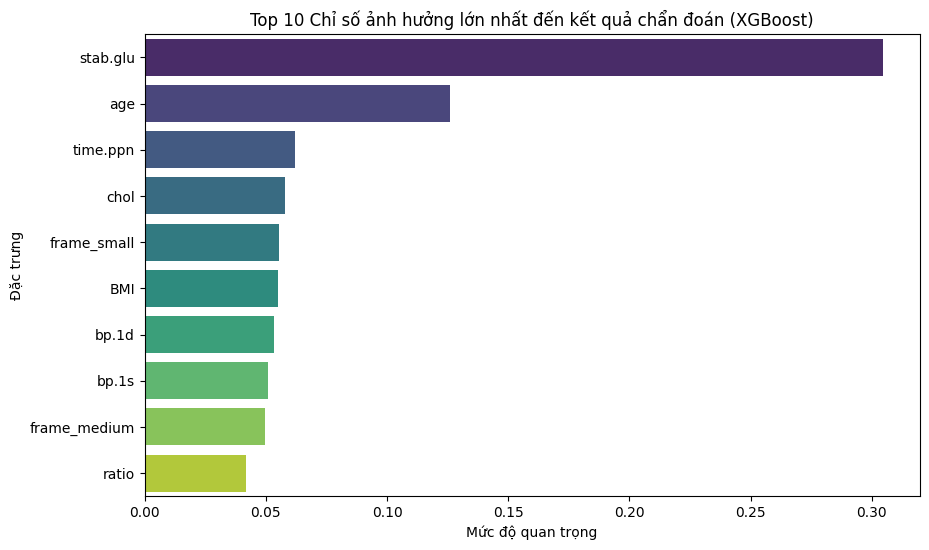

In [4]:
# 1. Rút trích mức độ quan trọng của từng đặc trưng
importances = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 2. Vẽ biểu đồ Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(data=importances.head(10), x='Importance', y='Feature', palette='viridis')

plt.title('Top 10 Chỉ số ảnh hưởng lớn nhất đến kết quả chẩn đoán (XGBoost)')
plt.xlabel('Mức độ quan trọng')
plt.ylabel('Đặc trưng')
plt.show()

In [5]:
# 1. Đặt tên cho file mô hình
model_filename = 'diabetes_xgb_model.pkl'

# 2. Lưu mô hình (xgb_model) xuống ổ cứng
joblib.dump(xgb_model, model_filename)

# (Tùy chọn) Lưu thêm danh sách các cột để đối chiếu dữ liệu web sau này
joblib.dump(X_encoded.columns.tolist(), 'model_features_xgb.pkl')

print("=== ĐÃ LƯU MÔ HÌNH THÀNH CÔNG ===")
print(f"File lưu tại: {model_filename}")

=== ĐÃ LƯU MÔ HÌNH THÀNH CÔNG ===
File lưu tại: diabetes_xgb_model.pkl
